<a href="https://colab.research.google.com/github/xyz111131/AI-Tools-for-Statistical-Research/blob/main/FashionMNIST_MLP_monitor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets  ## domain-specific library, include datasets
from torchvision.transforms import ToTensor

In [2]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs_range = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Training Loss')
    plt.plot(epochs_range, history['test_loss'], label='Test Loss')
    plt.title('Training and Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Training Accuracy')
    plt.plot(epochs_range, history['test_acc'], label='Test Accuracy')
    plt.title('Training and Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call this after training is finished
# plot_history(history)

# Download FashionMNIST data

In [3]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(), # convert to tensor and scale to [0,1]
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 308kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.68MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.7MB/s]


In [4]:
from torch.utils.data import random_split

try:
    # Split test_data into validation and test sets (50/50 split)
    val_size = len(test_data) // 2
    test_size = len(test_data) - val_size
    val_data, final_test_data = random_split(test_data, [val_size, test_size])

    print(f"Validation samples: {len(val_data)}")
    print(f"Test samples: {len(final_test_data)}")
except NameError:
    print("Error: 'test_data' is not defined. Please run cell K1gAHuJpa0p7 first.")

Validation samples: 5000
Test samples: 5000


The FashionMNIST dataset is a collection of 70,000 grayscale images of fashion articles, categorized into 10 classes. It serves as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms. Each image is 28x28 pixels.

In [5]:
training_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

# Construct DataLoader

iterate over dataset, supports batching, shuffling etc.

In [7]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

# Explanation of the tensor shape:
# N (Batch Size): 64 images are processed in one batch.
# C (Channels): 1, indicating a grayscale image (one color channel).
# H (Height): 28 pixels.
# W (Width): 28 pixels.

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [8]:
from torch.utils.data import DataLoader

batch_size = 64

try:
    train_dataloader = DataLoader(training_data, batch_size=batch_size)
    val_dataloader = DataLoader(val_data, batch_size=batch_size)
    test_dataloader = DataLoader(final_test_data, batch_size=batch_size)
    print("DataLoaders created successfully.")
except NameError as e:
    print(f"Error: {e}. Please ensure datasets and splits are initialized.")

DataLoaders created successfully.


# Create MLP model

In [9]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )
        self.activations = {}

    def get_activation(self, name):
        def hook(model, input, output):
            self.activations[name] = output.detach()
        return hook

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)

# Register hooks for monitoring activations
model.linear_relu_stack[0].register_forward_hook(model.get_activation('layer1_fc'))
model.linear_relu_stack[2].register_forward_hook(model.get_activation('layer2_fc'))
model.linear_relu_stack[4].register_forward_hook(model.get_activation('layer3_fc'))

print(model)

Using cuda device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


# Model training and testing

In [10]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [11]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()
    train_loss, correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        if batch % 100 == 0:
            loss_val, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss_val:>7f}  [{current:>5d}/{size:>5d}]")

    train_loss /= num_batches
    correct /= size
    return train_loss, correct

In [12]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_loss, correct

Epoch 1
-------------------------------
loss: 2.307933  [   64/60000]
loss: 2.301330  [ 6464/60000]
loss: 2.273914  [12864/60000]
loss: 2.262532  [19264/60000]
loss: 2.245252  [25664/60000]
loss: 2.213650  [32064/60000]
loss: 2.234512  [38464/60000]
loss: 2.197429  [44864/60000]
loss: 2.204278  [51264/60000]
loss: 2.158907  [57664/60000]
Test Error: 
 Accuracy: 32.5%, Avg loss: 2.158402 

Epoch 2
-------------------------------
loss: 2.169245  [   64/60000]
loss: 2.170303  [ 6464/60000]
loss: 2.108236  [12864/60000]
loss: 2.126041  [19264/60000]
loss: 2.075636  [25664/60000]
loss: 2.015148  [32064/60000]
loss: 2.056378  [38464/60000]
loss: 1.974926  [44864/60000]
loss: 1.990133  [51264/60000]
loss: 1.909831  [57664/60000]
Test Error: 
 Accuracy: 55.5%, Avg loss: 1.910567 

Epoch 3
-------------------------------
loss: 1.931911  [   64/60000]
loss: 1.918716  [ 6464/60000]
loss: 1.796150  [12864/60000]
loss: 1.840745  [19264/60000]
loss: 1.734703  [25664/60000]
loss: 1.678062  [32064/600

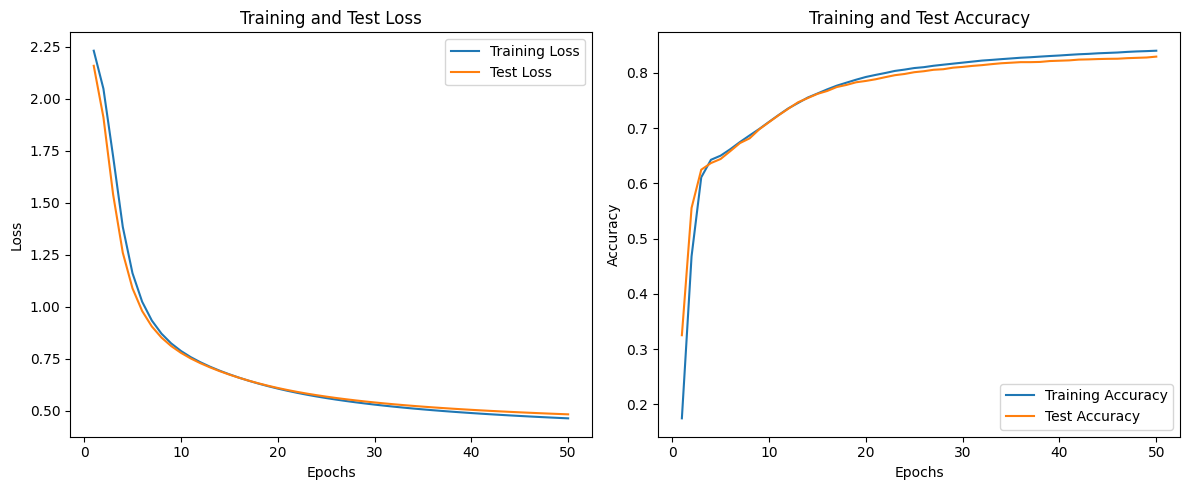

In [13]:
epochs = 50
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss, train_acc = train(train_dataloader, model, loss_fn, optimizer)
    # Using val_dataloader here to monitor validation performance
    val_loss, val_acc = test(val_dataloader, model, loss_fn)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(val_loss)
    history['test_acc'].append(val_acc)

print("Training Complete!")
plot_history(history)

In [14]:
print("Final Evaluation on Test Set:")
test(test_dataloader, model, loss_fn)

Final Evaluation on Test Set:
Test Error: 
 Accuracy: 82.2%, Avg loss: 0.505867 



(0.5058673541002636, 0.822)

# Saving Models

In [15]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


# Loading Models

In [16]:
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model.pth", weights_only=True))

<All keys matched successfully>

In [17]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()
x, y = test_data[0][0], test_data[0][1]
with torch.no_grad():
    x = x.to(device)
    pred = model(x.unsqueeze(0)) # Unsqueeze to add batch dimension
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"\n')

# Display Monitored Data
print("--- Activation Shapes ---")
for name, tensor in model.activations.items():
    print(f"{name}: {tensor.shape}")

print("\n--- Weight Shapes ---")
for name, param in model.named_parameters():
    if 'weight' in name:
        print(f"{name}: {param.shape}")

Predicted: "Ankle boot", Actual: "Ankle boot"

--- Activation Shapes ---

--- Weight Shapes ---
linear_relu_stack.0.weight: torch.Size([512, 784])
linear_relu_stack.2.weight: torch.Size([512, 512])
linear_relu_stack.4.weight: torch.Size([10, 512])


### Experiment: Inducing Oscillation
We will now use a much higher learning rate and a smaller batch size to observe how it affects the convergence and stability of the loss curve.

Epoch 1
loss: 2.296394  [    8/60000]
loss: 1.991723  [  808/60000]
loss: 2.189101  [ 1608/60000]
loss: 1.197147  [ 2408/60000]
loss: 1.632566  [ 3208/60000]
loss: 1.105585  [ 4008/60000]
loss: 2.771015  [ 4808/60000]
loss: 1.551280  [ 5608/60000]
loss: 1.371742  [ 6408/60000]
loss: 1.715668  [ 7208/60000]
loss: 1.591498  [ 8008/60000]
loss: 1.567724  [ 8808/60000]
loss: 1.705378  [ 9608/60000]
loss: 1.813882  [10408/60000]
loss: 2.679997  [11208/60000]
loss: 1.581285  [12008/60000]
loss: 1.423580  [12808/60000]
loss: 1.398440  [13608/60000]
loss: 1.579052  [14408/60000]
loss: 1.617476  [15208/60000]
loss: 1.850281  [16008/60000]
loss: 2.422701  [16808/60000]
loss: 2.247145  [17608/60000]
loss: 2.303792  [18408/60000]
loss: 2.365736  [19208/60000]
loss: 2.287526  [20008/60000]
loss: 2.360528  [20808/60000]
loss: 2.337449  [21608/60000]
loss: 2.316121  [22408/60000]
loss: 2.310377  [23208/60000]
loss: 2.402568  [24008/60000]
loss: 2.364377  [24808/60000]
loss: 2.235227  [25608/60000]
lo

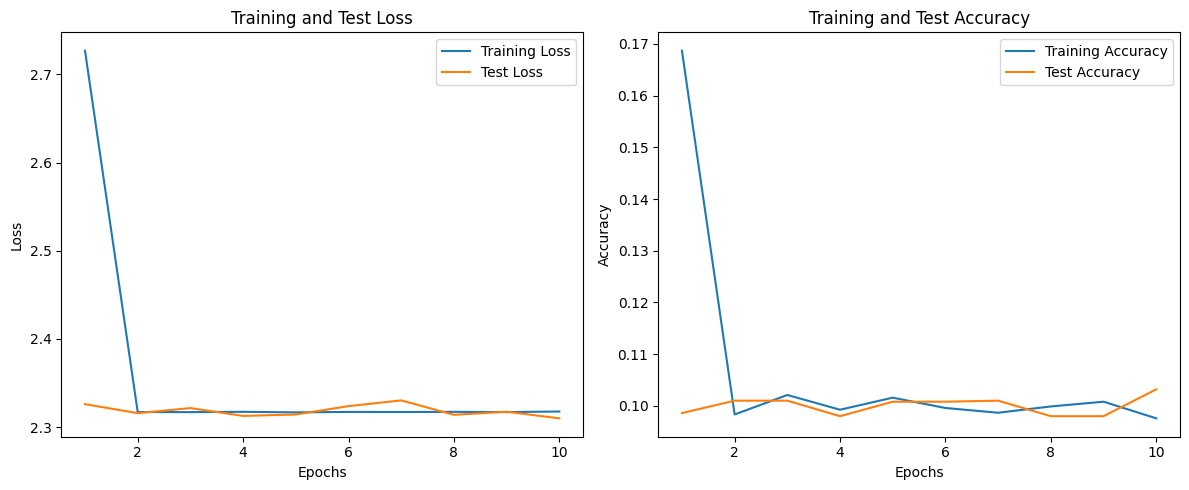

In [18]:
# Re-initialize the model to start from scratch
model_osc = NeuralNetwork().to(device)

# High learning rate and small batch size to induce oscillation
oscl_lr = 0.5
oscl_batch_size = 8

train_dataloader_osc = DataLoader(training_data, batch_size=oscl_batch_size, shuffle=True)
val_dataloader_osc = DataLoader(val_data, batch_size=oscl_batch_size)

loss_fn = nn.CrossEntropyLoss()
optimizer_osc = torch.optim.SGD(model_osc.parameters(), lr=oscl_lr)

epochs_osc = 10
history_osc = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for t in range(epochs_osc):
    print(f"Epoch {t+1}")
    train_loss, train_acc = train(train_dataloader_osc, model_osc, loss_fn, optimizer_osc)
    val_loss, val_acc = test(val_dataloader_osc, model_osc, loss_fn)

    history_osc['train_loss'].append(train_loss)
    history_osc['train_acc'].append(train_acc)
    history_osc['test_loss'].append(val_loss)
    history_osc['test_acc'].append(val_acc)

plot_history(history_osc)

### Experiment: Demonstrating Overfitting (Validation Loss Increases)
To show the validation loss increasing within 50 epochs, we can use a moderately high learning rate and a smaller batch size. This setup will cause the model to rapidly fit the training data but lose its ability to generalize, leading to a rise in validation loss (overfitting).

Starting Overfitting Experiment...
Epoch 1
loss: 2.309926  [   32/60000]
loss: 1.150296  [ 3232/60000]
loss: 0.893902  [ 6432/60000]
loss: 0.790930  [ 9632/60000]
loss: 0.686898  [12832/60000]
loss: 0.466427  [16032/60000]
loss: 0.723625  [19232/60000]
loss: 0.613630  [22432/60000]
loss: 0.533767  [25632/60000]
loss: 0.628255  [28832/60000]
loss: 0.768113  [32032/60000]
loss: 0.610384  [35232/60000]
loss: 0.646342  [38432/60000]
loss: 0.363146  [41632/60000]
loss: 0.426465  [44832/60000]
loss: 0.385785  [48032/60000]
loss: 0.475838  [51232/60000]
loss: 0.444143  [54432/60000]
loss: 0.563131  [57632/60000]
Test Error: 
 Accuracy: 83.5%, Avg loss: 0.453381 

Epoch 2
loss: 0.347188  [   32/60000]
loss: 0.379102  [ 3232/60000]
loss: 0.526457  [ 6432/60000]
loss: 0.271133  [ 9632/60000]
loss: 0.352396  [12832/60000]
loss: 0.685232  [16032/60000]
loss: 0.297175  [19232/60000]
loss: 0.308326  [22432/60000]
loss: 0.565963  [25632/60000]
loss: 0.316968  [28832/60000]
loss: 0.355212  [32032/6000

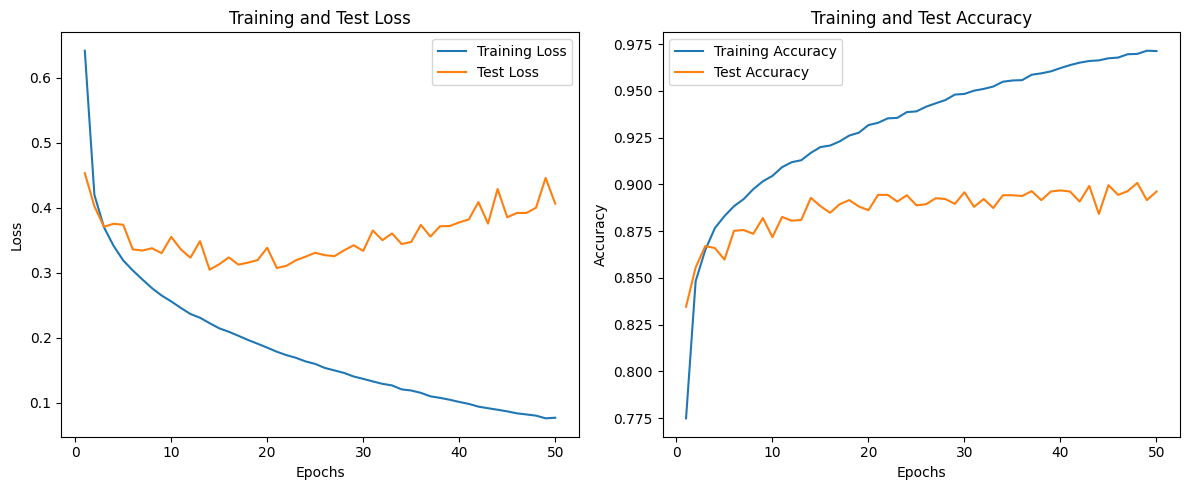

In [19]:
# Re-initialize the model to start from scratch
model_overfit = NeuralNetwork().to(device)

# Moderately high learning rate and smaller batch size
overfit_lr = 0.05
overfit_batch_size = 32

train_dataloader_of = DataLoader(training_data, batch_size=overfit_batch_size, shuffle=True)
val_dataloader_of = DataLoader(val_data, batch_size=overfit_batch_size)

loss_fn = nn.CrossEntropyLoss()
optimizer_of = torch.optim.SGD(model_overfit.parameters(), lr=overfit_lr)

epochs_of = 50
history_of = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

print("Starting Overfitting Experiment...")
for t in range(epochs_of):
    print(f"Epoch {t+1}")
    train_loss, train_acc = train(train_dataloader_of, model_overfit, loss_fn, optimizer_of)
    val_loss, val_acc = test(val_dataloader_of, model_overfit, loss_fn)

    history_of['train_loss'].append(train_loss)
    history_of['train_acc'].append(train_acc)
    history_of['test_loss'].append(val_loss)
    history_of['test_acc'].append(val_acc)

plot_history(history_of)